In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Make pandas show all columns when we print data
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("Libraries loaded successfully!")


Libraries loaded successfully!


In [5]:
print("\n Upload your matches.csv FILE")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f"\n File uploaded: {filename}")
print(f"   File size: {len(uploaded[filename]):,} bytes")


 Upload your matches.csv FILE


Saving matches.csv to matches.csv

 File uploaded: matches.csv
   File size: 107,599,180 bytes


In [6]:
print("\n" + "="*70)
print("STEP 1: LOADING BALL-BY-BALL DATA")
print("="*70)

# Load the CSV file
df = pd.read_csv(filename)

print(f"\n Data loaded successfully!")
print(f"   Total rows: {len(df):,} (each row is ONE ball bowled)")
print(f"   Total columns: {len(df.columns)}")
print(f"   Unique matches: {df['match_id'].nunique():,}")

# Show basic info about the data
print(f"\n📊 DATA OVERVIEW:")
print(f"   This is BALL-BY-BALL data")
print(f"   Every row = one delivery in a match")
print(f"   We'll aggregate this to MATCH-LEVEL data")

# Show first few rows
print("\n📋 First 3 balls of the dataset:")
print(df[['match_id', 'date', 'batting_team', 'batter', 'bowler',
         'runs_total', 'wicket_kind']].head(3))


STEP 1: LOADING BALL-BY-BALL DATA

 Data loaded successfully!
   Total rows: 283,678 (each row is ONE ball bowled)
   Total columns: 64
   Unique matches: 1,193

📊 DATA OVERVIEW:
   This is BALL-BY-BALL data
   Every row = one delivery in a match
   We'll aggregate this to MATCH-LEVEL data

📋 First 3 balls of the dataset:
   match_id      date           batting_team       batter   bowler  runs_total wicket_kind
0    335982  18-04-08  Kolkata Knight Riders   SC Ganguly  P Kumar           1         NaN
1    335982  18-04-08  Kolkata Knight Riders  BB McCullum  P Kumar           0         NaN
2    335982  18-04-08  Kolkata Knight Riders  BB McCullum  P Kumar           1         NaN


### **STEP 1: Understanding the data structure**

In [7]:
# Show all column names
print(f"\n📋 COLUMN NAMES ({len(df.columns)} total):")
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype  # Data type (int, float, text, etc.)
    print(f"  {i:2d}. {col:30s} (type: {dtype})")

# Check data types
print("\n📊 KEY COLUMNS WE'LL USE:")
print("  • match_id: Unique identifier for each match")
print("  • date: When match was played")
print("  • batting_team / bowling_team: Which teams")
print("  • runs_total: Runs scored on this ball")
print("  • wicket_kind: If wicket fell on this ball")
print("  • toss_winner: Who won the toss")
print("  • match_won_by: Who won the match")
print("  • venue, city: Where match was played")

# Show how many balls per match
balls_per_match = df.groupby('match_id').size()
print(f"\n📊 BALLS PER MATCH:")
print(f"   Average: {balls_per_match.mean():.0f} balls")
print(f"   Minimum: {balls_per_match.min()} balls")
print(f"   Maximum: {balls_per_match.max()} balls")


📋 COLUMN NAMES (64 total):
   1. match_id                       (type: int64)
   2. date                           (type: object)
   3. match_type                     (type: object)
   4. event_name                     (type: object)
   5. innings                        (type: int64)
   6. batting_team                   (type: object)
   7. bowling_team                   (type: object)
   8. over                           (type: int64)
   9. ball                           (type: int64)
  10. ball_no                        (type: float64)
  11. batter                         (type: object)
  12. bat_pos                        (type: int64)
  13. runs_batter                    (type: int64)
  14. balls_faced                    (type: int64)
  15. bowler                         (type: object)
  16. valid_ball                     (type: int64)
  17. runs_extras                    (type: int64)
  18. runs_total                     (type: int64)
  19. runs_bowler                    (type: i

### **STEP 2: Creating match-level metadata**

In [8]:
match_info = df.groupby('match_id').agg({
    'date': 'first',           # Match date (same for all balls)
    'venue': 'first',          # Stadium name
    'city': 'first',           # City where played
    'toss_winner': 'first',    # Who won toss
    'toss_decision': 'first',  # Bat/field decision
    'match_won_by': 'first',   # Winner team name
    'win_outcome': 'first',    # Win description
    'player_of_match': 'first',# Player of match
    'season': 'first',         # IPL season
    'year': 'first',           # Year (now fixed!)
    'month': 'first',          # Month
    'day': 'first'             # Day
}).reset_index()

# EXPLANATION OF reset_index():
# - groupby() makes match_id the index (row label)
# - reset_index() converts it back to a regular column
# - This makes the data easier to work with

print(f"✅ Extracted metadata for {len(match_info):,} matches")

print(f"\n📋 Sample of match metadata:")
print(match_info[['match_id', 'date', 'venue', 'match_won_by']].head(3))

✅ Extracted metadata for 1,193 matches

📋 Sample of match metadata:
   match_id      date                                       venue           match_won_by
0    335982  18-04-08                       M Chinnaswamy Stadium  Kolkata Knight Riders
1    335983  19-04-08  Punjab Cricket Association Stadium, Mohali    Chennai Super Kings
2    335984  19-04-08                            Feroz Shah Kotla       Delhi Daredevils


### **STEP 3: Calculating Innings Scores**

In [9]:
# Calculate runs and wickets for each innings
# EXPLANATION:
# - Group by: match_id, innings, batting_team
# - Sum 'runs_total': Add up all runs in that innings
# - Count wickets: Count how many balls had a wicket
innings_scores = df.groupby(['match_id', 'innings', 'batting_team']).agg({
    'runs_total': 'sum',                           # Total runs
    'wicket_kind': lambda x: x.notna().sum()       # Count wickets
    # lambda x: x.notna().sum() means:
    # - x.notna() = True if wicket fell, False if not
    # - .sum() counts the True values
}).reset_index()

# Rename columns for clarity
innings_scores.columns = ['match_id', 'innings', 'team', 'runs', 'wickets']

print(f"✅ Calculated scores for {len(innings_scores):,} innings")
print(f"   Total matches: {innings_scores['match_id'].nunique():,}")

# Show sample
print(f"\n📋 Sample innings scores:")
print(innings_scores.head(6))  # Show first 6 (3 matches = 6 innings)

✅ Calculated scores for 2,412 innings
   Total matches: 1,193

📋 Sample innings scores:
   match_id  innings                         team  runs  wickets
0    335982        1        Kolkata Knight Riders   222        3
1    335982        2  Royal Challengers Bangalore    82       10
2    335983        1          Chennai Super Kings   240        5
3    335983        2              Kings XI Punjab   207        4
4    335984        1             Rajasthan Royals   129        8
5    335984        2             Delhi Daredevils   132        1


### **STEP 4: Innings to Match format**

In [10]:
# Separate innings 1 and innings 2
# EXPLANATION: Filter rows where innings == 1 or innings == 2
innings1 = innings_scores[innings_scores['innings'] == 1].copy()
innings2 = innings_scores[innings_scores['innings'] == 2].copy()

# Rename columns to distinguish team1 vs team2
innings1.columns = ['match_id', 'innings', 'team1', 'team1_runs', 'team1_wickets']
innings2.columns = ['match_id', 'innings', 'team2', 'team2_runs', 'team2_wickets']

# Merge innings 1 and innings 2 into single row per match
# EXPLANATION: merge() combines two tables based on matching match_id
#              Like a JOIN in SQL
match_scores = innings1[['match_id', 'team1', 'team1_runs', 'team1_wickets']].merge(
    innings2[['match_id', 'team2', 'team2_runs', 'team2_wickets']],
    on='match_id',      # Join on matching match_id
    how='outer'         # Keep all matches even if data missing
)

print(f"✅ Created match-level scores")
print(f"   One row per match: {len(match_scores):,}")

# Show result
print(f"\n📋 Sample of match format:")
print(match_scores[['match_id', 'team1', 'team1_runs', 'team2', 'team2_runs']].head(3))

✅ Created match-level scores
   One row per match: 1,193

📋 Sample of match format:
   match_id                  team1  team1_runs                        team2  team2_runs
0    335982  Kolkata Knight Riders         222  Royal Challengers Bangalore        82.0
1    335983    Chennai Super Kings         240              Kings XI Punjab       207.0
2    335984       Rajasthan Royals         129             Delhi Daredevils       132.0


### **STEP 5: Merging the Data**

In [11]:
# Merge match info with match scores
# EXPLANATION: Combine tables on matching match_id
matches = match_info.merge(
    match_scores,
    on='match_id',    # Column to match on
    how='left'        # Keep all matches from match_info
)

print(f"✅ Created complete match dataset")
print(f"   Total matches: {len(matches):,}")
print(f"   Total columns: {len(matches.columns)}")

# Show final structure
print(f"\n📋 Final match dataset structure:")
print(matches.head(3))

✅ Created complete match dataset
   Total matches: 1,193
   Total columns: 19

📋 Final match dataset structure:
   match_id      date                                       venue        city                  toss_winner toss_decision           match_won_by win_outcome player_of_match   season  year  month  day                  team1  team1_runs  team1_wickets                        team2  team2_runs  team2_wickets
0    335982  18-04-08                       M Chinnaswamy Stadium   Bangalore  Royal Challengers Bangalore         field  Kolkata Knight Riders    140 runs     BB McCullum  2007/08  2008      4   18  Kolkata Knight Riders         222              3  Royal Challengers Bangalore        82.0           10.0
1    335983  19-04-08  Punjab Cricket Association Stadium, Mohali  Chandigarh          Chennai Super Kings           bat    Chennai Super Kings     33 runs      MEK Hussey  2007/08  2008      4   19    Chennai Super Kings         240              5              Kings XI Punjab 

### **STEP 6: Handling missing data**

In [12]:
# Check for missing data
print("\n📊 CHECKING FOR MISSING DATA:")
missing_data = matches.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

if len(missing_data) > 0:
    print(f"\n⚠️  Found missing data in {len(missing_data)} columns:")
    for col, count in missing_data.items():
        pct = (count / len(matches) * 100)
        print(f"   • {col}: {count} ({pct:.1f}%)")
else:
    print("✅ No missing data found!")

# Fix missing cities using venue mapping

if matches['city'].isnull().sum() > 0:
    # Create venue → city mapping from known data
    # EXPLANATION: For each venue, find most common city
    city_map = matches[matches['city'].notna()].groupby('venue')['city'].first().to_dict()

    # Fill missing cities
    matches['city'].fillna(matches['venue'].map(city_map), inplace=True)
    matches['city'].fillna('Unknown', inplace=True)
    print(f"   ✓ Fixed missing cities")

# Handle matches with no result
if matches['match_won_by'].isnull().sum() > 0:
    matches['match_won_by'].fillna('No Result', inplace=True)
    print(f"    Marked {matches['match_won_by'].isnull().sum()} no-result matches")

print("\n✅ Data cleaning complete!")


📊 CHECKING FOR MISSING DATA:

⚠️  Found missing data in 4 columns:
   • win_outcome: 24 (2.0%)
   • team2: 6 (0.5%)
   • team2_runs: 6 (0.5%)
   • team2_wickets: 6 (0.5%)

✅ Data cleaning complete!


### **STEP 7: Feature Engineering - Win Margin**

In [ ]:
# Function to calculate win margin
def calculate_win_margin(row):

    # Get values, handle missing data
    team1_runs = row.get('team1_runs', 0) or 0
    team2_runs = row.get('team2_runs', 0) or 0
    team2_wickets = row.get('team2_wickets', 0) or 0

    # Handle missing scores
    if pd.isna(team1_runs) or pd.isna(team2_runs):
        return 'No Result', 0

    # Determine winner and margin
    if team1_runs > team2_runs:
        # Team 1 won batting first
        margin = team1_runs - team2_runs
        return 'runs', margin
    elif team2_runs > team1_runs:
        # Team 2 won chasing
        # Margin = wickets remaining (10 - wickets lost)
        margin = 10 - team2_wickets
        return 'wickets', margin
    else:
        # Tie game
        return 'tie', 0

# Apply function to every row
# EXPLANATION: .apply() runs our function on each row
#              result_type='expand' splits tuple into 2 columns
matches[['win_margin_type', 'win_margin_value']] = matches.apply(
    calculate_win_margin,
    axis=1,                    # Apply to each row
    result_type='expand'       # Split result into 2 columns
)

print("✅ Added columns:")
print("   • win_margin_type (runs/wickets/tie/no result)")
print("   • win_margin_value (margin amount)")

# Show distribution
print(f"\n📊 Win Type Distribution:")
print(matches['win_margin_type'].value_counts())

# Show examples
print(f"\n📋 Examples:")
print(matches[['team1', 'team1_runs', 'team2', 'team2_runs',
               'win_margin_type', 'win_margin_value']].head(5))

✅ Added columns:
   • win_margin_type (runs/wickets/tie/no result)
   • win_margin_value (margin amount)

📊 Win Type Distribution:
win_margin_type
wickets      621
runs         551
tie           15
No Result      6
Name: count, dtype: int64

📋 Examples:
                   team1  team1_runs                        team2  team2_runs win_margin_type  win_margin_value
0  Kolkata Knight Riders         222  Royal Challengers Bangalore        82.0            runs             140.0
1    Chennai Super Kings         240              Kings XI Punjab       207.0            runs              33.0
2       Rajasthan Royals         129             Delhi Daredevils       132.0         wickets               9.0
3         Mumbai Indians         165  Royal Challengers Bangalore       166.0         wickets               5.0
4        Deccan Chargers         110        Kolkata Knight Riders       112.0         wickets               5.0


### **STEP 8: Feature Engineering - Toss Impact**

In [ ]:
# Compare toss winner with match winner
# EXPLANATION:
# - (A == B) returns True/False
# - .astype(int) converts True→1, False→0
matches['toss_match_win'] = (
    matches['toss_winner'] == matches['match_won_by']
).astype(int)

# Calculate percentage
toss_wins = matches['toss_match_win'].sum()
total_matches = len(matches)
toss_pct = (toss_wins / total_matches * 100).round(1)

print(f"✅ Added 'toss_match_win' column")
print(f"\n📊 TOSS IMPACT ANALYSIS:")
print(f"   Toss winners who won match: {toss_wins}")
print(f"   Total matches: {total_matches}")
print(f"   Success rate: {toss_pct}%")

if toss_pct > 55:
    print(f"      Insight: Winning toss provides SIGNIFICANT advantage!")
elif toss_pct < 45:
    print(f"      Insight: Toss doesn't matter much")
else:
    print(f"      Insight: Toss impact is balanced (~50/50)")

✅ Added 'toss_match_win' column

📊 TOSS IMPACT ANALYSIS:
   Toss winners who won match: 606
   Total matches: 1193
   Success rate: 50.8%
      Insight: Toss impact is balanced (~50/50)


### **STEP 9: Feature Engineering - Home/Away**

In [ ]:
# Define home city for each team
# EXPLANATION: Dictionary maps team name → home city
home_cities = {
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Royal Challengers Bangalore': 'Bangalore',
    'Rajasthan Royals': 'Jaipur',
    'Delhi Capitals': 'Delhi',
    'Delhi Daredevils': 'Delhi',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Punjab Kings': 'Mohali',
    'Kings XI Punjab': 'Mohali',
    'Gujarat Titans': 'Ahmedabad',
    'Lucknow Super Giants': 'Lucknow',
    'Rising Pune Supergiants': 'Pune',
    'Rising Pune Supergiant': 'Pune',
    'Deccan Chargers': 'Hyderabad',
    'Kochi Tuskers Kerala': 'Kochi',
    'Pune Warriors': 'Pune'
}

# Check if team1 playing at home
# EXPLANATION: If team's home city matches match city → 1, else 0
matches['team1_home'] = matches.apply(
    lambda row: 1 if home_cities.get(row.get('team1', ''), '') == row.get('city', '') else 0,
    axis=1
)

# Check if team2 playing at home
matches['team2_home'] = matches.apply(
    lambda row: 1 if home_cities.get(row.get('team2', ''), '') == row.get('city', '') else 0,
    axis=1
)

home_count = matches['team1_home'].sum() + matches['team2_home'].sum()
home_pct = (home_count / len(matches) * 100).round(1)

print(f"✅ Added home/away indicators")
print(f"📊 {home_count} home matches ({home_pct}%)")

✅ Added home/away indicators
📊 674 home matches (56.5%)


### **STEP 10: Feature Engineering - More Features**

In [ ]:
# 1. CLOSE MATCH INDICATOR
print("\n  Identifying close matches...")
# Close = Won by ≤10 runs OR ≤3 wickets
matches['close_match'] = (
    ((matches['win_margin_type'] == 'runs') & (matches['win_margin_value'] <= 10)) |
    ((matches['win_margin_type'] == 'wickets') & (matches['win_margin_value'] <= 3))
).astype(int)

close_count = matches['close_match'].sum()
close_pct = (close_count / len(matches) * 100).round(1)
print(f"✅ Close matches: {close_count} ({close_pct}%)")

# 2. HIGH SCORING INDICATOR
print("\n  Identifying high-scoring matches...")
# High scoring = Either team scored 200+
matches['high_scoring'] = (
    (matches['team1_runs'] >= 200) | (matches['team2_runs'] >= 200)
).astype(int)

high_scoring_count = matches['high_scoring'].sum()
print(f"✅ High-scoring matches (200+): {high_scoring_count}")

# 3. TOTAL MATCH RUNS
print("\n Calculating total runs...")
matches['total_runs'] = matches['team1_runs'].fillna(0) + matches['team2_runs'].fillna(0)
avg_runs = matches['total_runs'].mean()
print(f"✅ Average runs per match: {avg_runs:.0f}")

# 4. DATE FEATURES
print("\n  Creating date features...")
# Convert date string to datetime
matches['date'] = pd.to_datetime(matches['date'], format='%y-%m-%d', errors='coerce')

# Extract day of week
matches['day_of_week'] = matches['date'].dt.day_name()

# Weekend indicator
matches['is_weekend'] = matches['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

weekend_count = matches['is_weekend'].sum()
weekend_pct = (weekend_count / len(matches) * 100).round(1)
print(f"✅ Weekend matches: {weekend_count} ({weekend_pct}%)")



  Identifying close matches...
✅ Close matches: 174 (14.6%)

  Identifying high-scoring matches...
✅ High-scoring matches (200+): 197

 Calculating total runs...
✅ Average runs per match: 321

  Creating date features...
✅ Weekend matches: 335 (28.1%)


### **STEP 11 : Player Statistics**

In [ ]:
# Aggregate batting stats
batter_stats = df.groupby('batter').agg({
    'runs_batter': 'sum',        # Total runs scored
    'balls_faced': 'sum',        # Total balls faced
    'match_id': 'nunique'        # Number of matches
}).reset_index()

# Rename columns
batter_stats.columns = ['player', 'runs', 'balls', 'matches']

# Calculate strike rate
# EXPLANATION: Strike rate = (runs / balls) * 100
batter_stats['strike_rate'] = (batter_stats['runs'] / batter_stats['balls'] * 100).round(2)

# Sort by runs
batter_stats = batter_stats.sort_values('runs', ascending=False)

print(f"✅ Stats for {len(batter_stats):,} batters")
print(f"\n📊 TOP 10 RUN SCORERS:")
print(batter_stats[['player', 'runs', 'balls', 'strike_rate', 'matches']].head(10).to_string(index=False))

# Bowling stats
print("\n  Calculating top bowler stats...")

bowler_stats = df[df['wicket_kind'].notna()].groupby('bowler').agg({
    'wicket_kind': 'count',      # Count wickets
    'match_id': 'nunique'        # Number of matches
}).reset_index()

bowler_stats.columns = ['player', 'wickets', 'matches']
bowler_stats = bowler_stats.sort_values('wickets', ascending=False)

print(f"✅ Stats for {len(bowler_stats):,} bowlers")
print(f"\n📊 TOP 10 WICKET TAKERS:")
print(bowler_stats[['player', 'wickets', 'matches']].head(10).to_string(index=False))

✅ Stats for 719 batters

📊 TOP 10 RUN SCORERS:
        player  runs  balls  strike_rate  matches
       V Kohli  8899   6667       133.48      264
     RG Sharma  7185   5420       132.56      270
      S Dhawan  6769   5326       127.09      221
     DA Warner  6567   4702       139.66      184
      SK Raina  5536   4046       136.83      200
      MS Dhoni  5439   3957       137.45      241
      KL Rahul  5346   3914       136.59      139
     AM Rahane  5184   4127       125.61      188
AB de Villiers  5181   3411       151.89      170
      CH Gayle  4997   3346       149.34      141

  Calculating top bowler stats...
✅ Stats for 483 bowlers

📊 TOP 10 WICKET TAKERS:
    player  wickets  matches
 YS Chahal      233      134
   B Kumar      220      130
 SP Narine      215      128
  DJ Bravo      207      118
  R Ashwin      205      137
 JJ Bumrah      204      101
 PP Chawla      201      128
SL Malinga      188       94
  A Mishra      183      107
 RA Jadeja      182      111


### **STEP 12 : Visualizations**

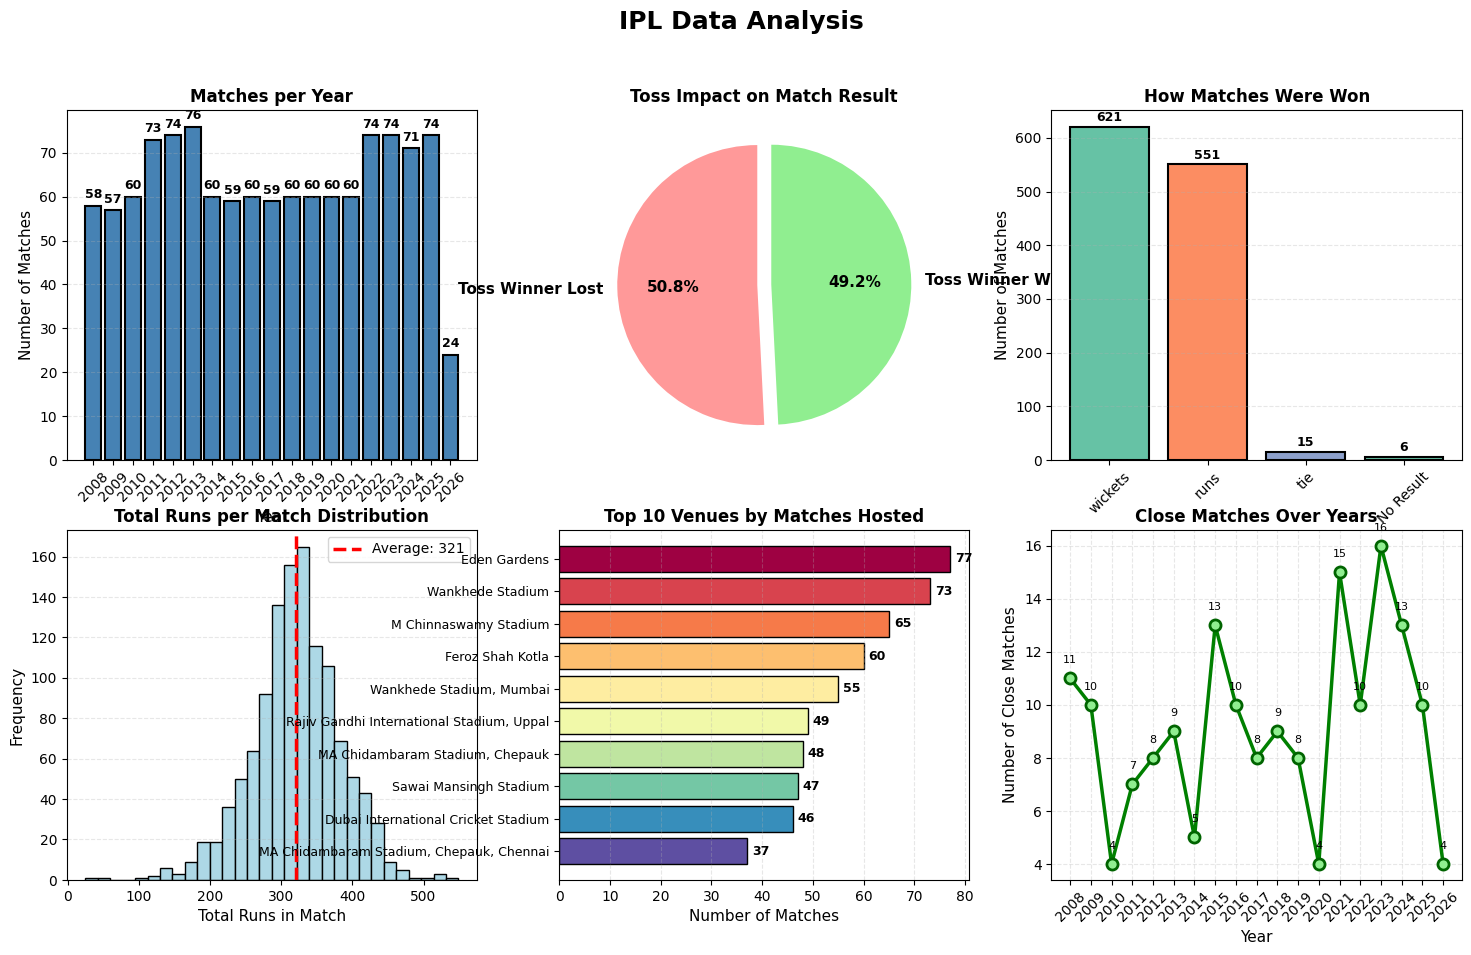

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create figure with 6 subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('IPL Data Analysis', fontsize=18, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 1: MATCHES PER SEASON
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

season_counts = matches['year'].value_counts().sort_index()

# Plot the bars
axes[0, 0].bar(season_counts.index, season_counts.values,
               color='steelblue', edgecolor='black', linewidth=1.5)


unique_seasons = sorted(matches['year'].unique())
axes[0, 0].set_xticks(unique_seasons)  # Position of ticks
axes[0, 0].set_xticklabels([int(s) for s in unique_seasons])  # Labels (as integers)

axes[0, 0].set_title('Matches per Year', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Year', fontsize=11)
axes[0, 0].set_ylabel('Number of Matches', fontsize=11)
axes[0, 0].tick_params(axis='x', rotation=45)
axes[0, 0].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars
for i, (season, count) in enumerate(season_counts.items()):
    axes[0, 0].text(season, count + 1, str(count),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 2: TOSS IMPACT
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

toss_counts = matches['toss_match_win'].value_counts()
labels = ['Toss Winner Lost', 'Toss Winner Won']
colors = ['#ff9999', '#90ee90']
explode = (0.05, 0.05)  # Slightly separate slices

axes[0, 1].pie(toss_counts.values, labels=labels, autopct='%1.1f%%',
               colors=colors, startangle=90, explode=explode,
               textprops={'fontsize': 11, 'fontweight': 'bold'})
axes[0, 1].set_title('Toss Impact on Match Result', fontsize=12, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 3: WIN MARGIN TYPES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

margin_counts = matches['win_margin_type'].value_counts()
colors_margin = ['#66c2a5', '#fc8d62', '#8da0cb']

axes[0, 2].bar(margin_counts.index, margin_counts.values,
               color=colors_margin[:len(margin_counts)], edgecolor='black', linewidth=1.5)
axes[0, 2].set_title('How Matches Were Won', fontsize=12, fontweight='bold')
axes[0, 2].set_ylabel('Number of Matches', fontsize=11)
axes[0, 2].tick_params(axis='x', rotation=45)
axes[0, 2].grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels
for i, (margin_type, count) in enumerate(margin_counts.items()):
    axes[0, 2].text(i, count + 5, str(count),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 4: TOTAL RUNS DISTRIBUTION
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

total_runs_clean = matches['total_runs'].dropna()
avg_runs = total_runs_clean.mean()

axes[1, 0].hist(total_runs_clean, bins=30, color='lightblue',
                edgecolor='black', linewidth=1)
axes[1, 0].set_title('Total Runs per Match Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Total Runs in Match', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].axvline(avg_runs, color='red', linestyle='--',
                   linewidth=2.5, label=f'Average: {avg_runs:.0f}')
axes[1, 0].legend(fontsize=10)
axes[1, 0].grid(axis='y', alpha=0.3, linestyle='--')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 5: TOP VENUES
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

top_venues = matches['venue'].value_counts().head(10)
colors_venues = plt.cm.Spectral(np.linspace(0, 1, len(top_venues)))

axes[1, 1].barh(range(len(top_venues)), top_venues.values,
                color=colors_venues, edgecolor='black', linewidth=1)
axes[1, 1].set_yticks(range(len(top_venues)))
axes[1, 1].set_yticklabels(top_venues.index, fontsize=9)
axes[1, 1].set_title('Top 10 Venues by Matches Hosted', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Number of Matches', fontsize=11)
axes[1, 1].invert_yaxis()
axes[1, 1].grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, count in enumerate(top_venues.values):
    axes[1, 1].text(count + 1, i, str(count),
                    va='center', fontsize=9, fontweight='bold')

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CHART 6: CLOSE MATCHES TREND
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

close_by_season = matches.groupby('year')['close_match'].sum().sort_index()

axes[1, 2].plot(close_by_season.index, close_by_season.values,
                marker='o', color='green', linewidth=2.5, markersize=8,
                markerfacecolor='lightgreen', markeredgecolor='darkgreen', markeredgewidth=2)


unique_seasons_close = sorted(close_by_season.index.unique())
axes[1, 2].set_xticks(unique_seasons_close)
axes[1, 2].set_xticklabels([int(s) for s in unique_seasons_close])

axes[1, 2].set_title('Close Matches Over Years', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Year', fontsize=11)
axes[1, 2].set_ylabel('Number of Close Matches', fontsize=11)
axes[1, 2].tick_params(axis='x', rotation=45)
axes[1, 2].grid(alpha=0.3, linestyle='--')

# Add value labels on data points
for season, count in zip(close_by_season.index, close_by_season.values):
    axes[1, 2].text(season, count + 0.5, str(count),
                    ha='center', va='bottom', fontsize=8)



### **STEP 13 : Summary of Insights**


In [ ]:
# Toss impact
toss_pct = (matches['toss_match_win'].sum() / len(matches) * 100).round(1)
print(f"\n🎯 TOSS IMPACT:")
print(f"   • {toss_pct}% of toss winners won the match")
if toss_pct > 55:
    print(f"   → Winning toss provides significant advantage!")
else:
    print(f"   → Toss impact is relatively balanced")

# Close matches
close_pct = (matches['close_match'].sum() / len(matches) * 100).round(1)
print(f"\n🎯 CLOSE MATCHES:")
print(f"   • {close_pct}% of matches were thriller finishes")
print(f"   → Definition: Won by ≤10 runs or ≤3 wickets")

# Average runs
avg_runs = matches['total_runs'].mean()
print(f"\n🎯 SCORING PATTERNS:")
print(f"   • Average total runs per match: {avg_runs:.0f}")
high_scoring_count = matches['high_scoring'].sum()
high_pct = (high_scoring_count / len(matches) * 100).round(1)
print(f"   • High-scoring matches (200+): {high_scoring_count} ({high_pct}%)")

# Weekend matches
weekend_pct = (matches['is_weekend'].sum() / len(matches) * 100).round(1)
print(f"\n🎯 SCHEDULING:")
print(f"   • {weekend_pct}% of matches on weekends")

# Home advantage
home_count = matches['team1_home'].sum() + matches['team2_home'].sum()
home_pct = (home_count / len(matches) * 100).round(1)
print(f"\n🎯 HOME ADVANTAGE:")
print(f"   • {home_count} matches ({home_pct}%) played at home venue")

# Top performers
print(f"\n🎯 TOP PERFORMERS:")
print(f"   • Highest scorer: {batter_stats.iloc[0]['player']} ({batter_stats.iloc[0]['runs']} runs)")
print(f"   • Most wickets: {bowler_stats.iloc[0]['player']} ({bowler_stats.iloc[0]['wickets']} wickets)")


🎯 TOSS IMPACT:
   • 50.8% of toss winners won the match
   → Toss impact is relatively balanced

🎯 CLOSE MATCHES:
   • 14.6% of matches were thriller finishes
   → Definition: Won by ≤10 runs or ≤3 wickets

🎯 SCORING PATTERNS:
   • Average total runs per match: 321
   • High-scoring matches (200+): 197 (16.5%)

🎯 SCHEDULING:
   • 28.1% of matches on weekends

🎯 HOME ADVANTAGE:
   • 674 matches (56.5%) played at home venue

🎯 TOP PERFORMERS:
   • Highest scorer: V Kohli (8899 runs)
   • Most wickets: YS Chahal (233 wickets)


### **STEP 14: Downloading Cleaned Dataset**

In [ ]:
# 1. Save match-level data
matches.to_csv('matches_cleaned.csv', index=False)
print("✅ matches_cleaned.csv ready")
print(f"   • {len(matches):,} matches")
print(f"   • {len(matches.columns)} columns")

# 2. Save batter stats
batter_stats.to_csv('top_batters.csv', index=False)
print("✅ top_batters.csv ready")
print(f"   • {len(batter_stats):,} players")

# 3. Save bowler stats
bowler_stats.to_csv('top_bowlers.csv', index=False)
print("✅ top_bowlers.csv ready")
print(f"   • {len(bowler_stats):,} players")

# 4. Create data dictionary
with open('data_dictionary.txt', 'w') as f:
    f.write("IPL DASHBOARD - DATA DICTIONARY\n")
    f.write("="*70 + "\n\n")
    f.write(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    f.write(f"SUMMARY:\n")
    f.write(f"  • Total matches: {len(matches):,}\n")
    f.write(f"  • Date range: {matches['date'].min()} to {matches['date'].max()}\n")
    f.write(f"  • Seasons: {matches['season'].nunique()}\n\n")
    f.write("NEW COLUMNS CREATED:\n")
    new_cols = ['win_margin_type', 'win_margin_value', 'toss_match_win',
                'team1_home', 'team2_home', 'close_match', 'high_scoring',
                'total_runs', 'day_of_week', 'is_weekend']
    for col in new_cols:
        f.write(f"  • {col}\n")


files.download('matches_cleaned.csv')
files.download('top_batters.csv')
files.download('top_bowlers.csv')
files.download('data_dictionary.txt')

print("\n✅ All files downloaded successfully!")

✅ matches_cleaned.csv ready
   • 1,193 matches
   • 29 columns
✅ top_batters.csv ready
   • 719 players
✅ top_bowlers.csv ready
   • 483 players


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All files downloaded successfully!
